In [86]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score,cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [87]:
# Set random seed for reproducibility
np.random.seed(42)

In [88]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [89]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [90]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [91]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [92]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [93]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

In [94]:
# Create SVM classifier
svm = SVC(random_state=42)

In [95]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [96]:
# Start timing
start_time = time.time()


In [97]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             return_train_score=True, scoring='accuracy')

In [98]:
# End timing
grid_time = time.time() - start_time

In [99]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 6.79 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [100]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [101]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

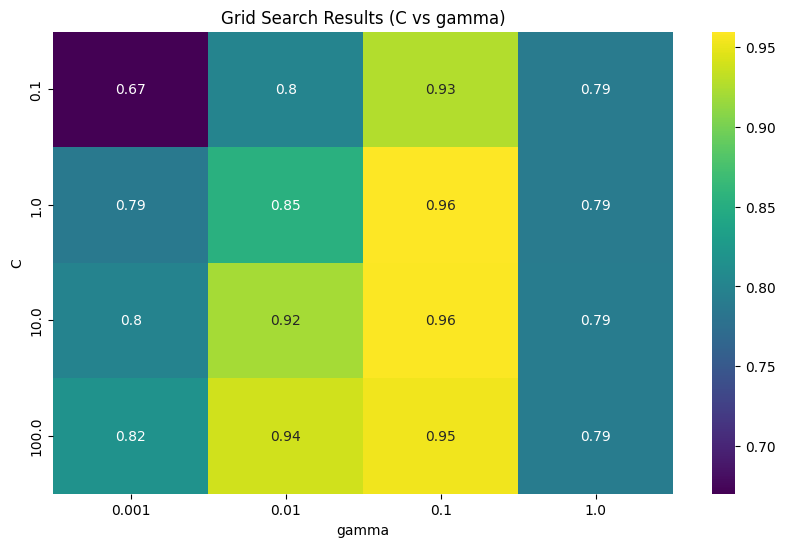

In [102]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [103]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [104]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [105]:
# Start timing
start_time = time.time()

In [106]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000281BB5A44B0>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000281BDC0F700>,
                                        'kernel': ['rbf', 'poly']},
                   random_state=42, return_train_score=True,
                   scoring='accuracy')

In [107]:
# End timing
random_time = time.time() - start_time

In [108]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 0.24 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [109]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [110]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456            6.787707
1  Random Search       0.971429       0.964912            0.243111


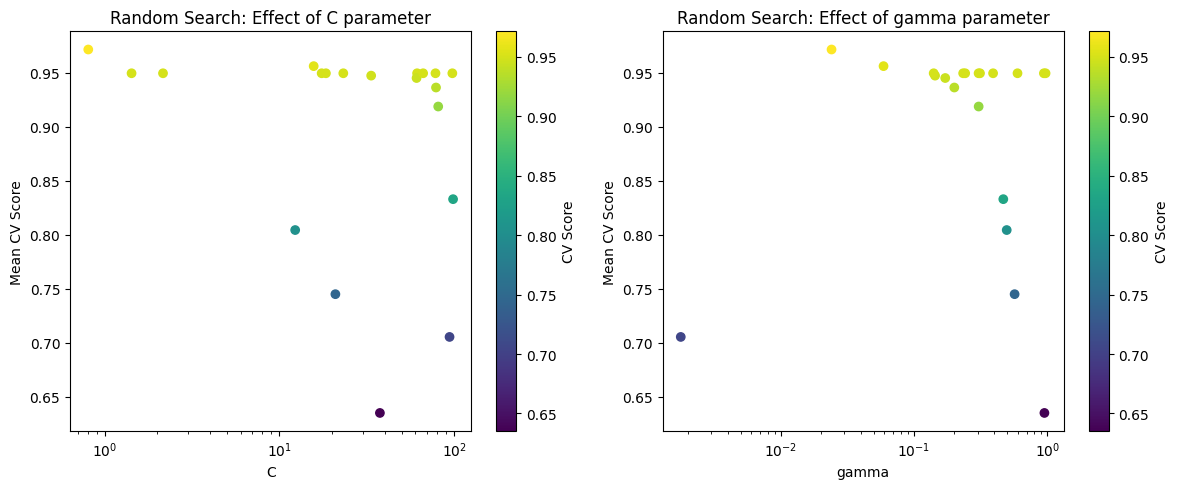

In [111]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [112]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

In [113]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [114]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [115]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [116]:
# Start timing
start_time = time.time()

In [117]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

BayesSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
              random_state=42, return_train_score=True, scoring='accuracy',
              search_spaces={'C': Real(low=0.1, high=100, prior='log-uniform', transform='normalize'),
                             'gamma': Real(low=0.001, high=1.0, prior='log-uniform', transform='normalize'),
                             'kernel': Categorical(categories=('rbf', 'poly'), prior=None)})

In [118]:
# End timing
bayes_time = time.time() - start_time

In [119]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 10.67 seconds
Best parameters: OrderedDict({'C': 47.479208101335, 'gamma': 0.015041969444180125, 'kernel': 'rbf'})
Best cross-validation score: 0.9626


In [120]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [121]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            6.787707
1          Random Search       0.971429       0.964912            0.243111
2  Bayesian Optimization       0.962637       0.956140           10.668557


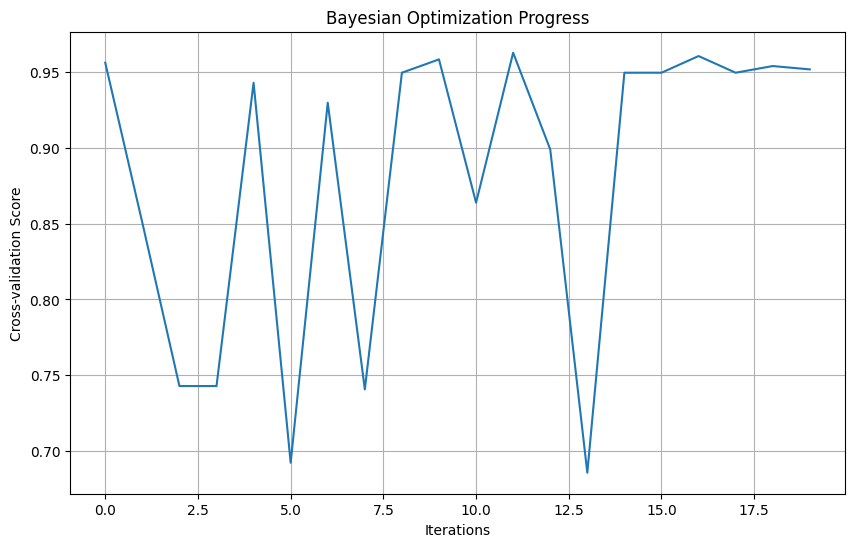

In [122]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [123]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [124]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['auto', 'sqrt', 'log2', None]
}

In [125]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [126]:
# Start timing
start_time = time.time()

In [127]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

c:\Users\Lenovo\miniconda3\envs\python_ml\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Lenovo\miniconda3\envs\python_ml\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\miniconda3\envs\python_ml\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Lenovo\miniconda3\envs\python_ml\Lib\site-packages

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regressor__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000281B8BBA3F0>,
                                        'regressor__max_features': ['auto',
                                                                    'sqrt',
                                                                    'log2',
                                                                    None],
                                        'regressor__min_sa...astructure.rv_discrete_frozen object at 0x00000281BB0351D0>,
                                        'regressor__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000281BAF0C9B0>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000281BB9E7E50>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [128]:
# End timing
rf_random_time = time.time() - start_time

In [129]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 2.47 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [130]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [131]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

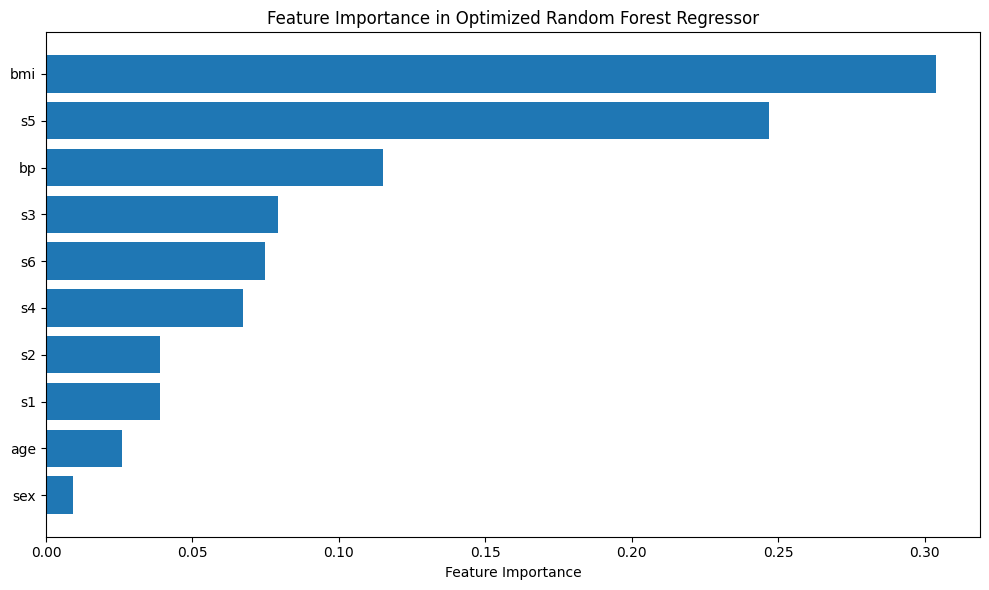

In [132]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [133]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [134]:
from sklearn.model_selection import learning_curve


In [135]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

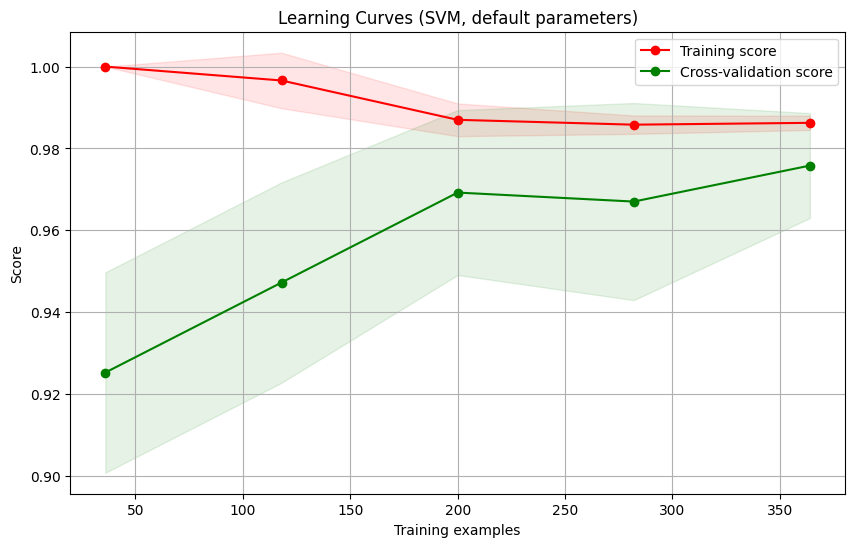

In [136]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

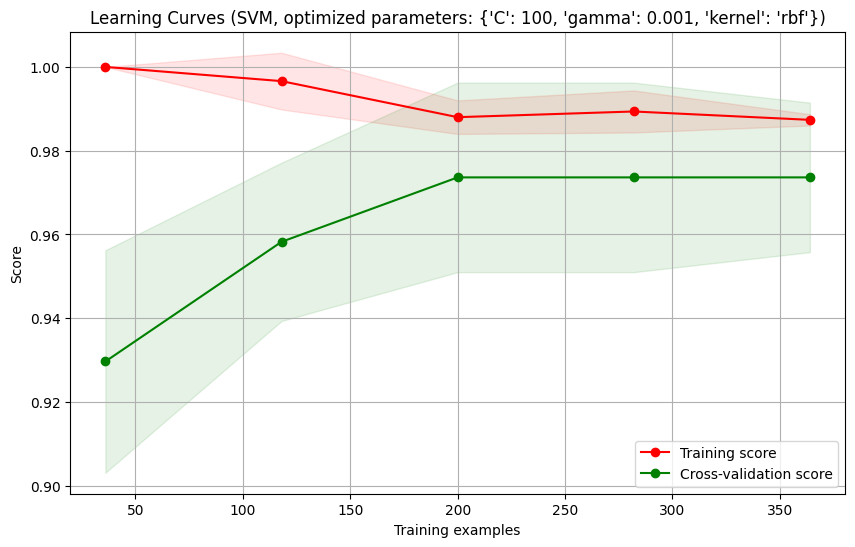

In [137]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [138]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

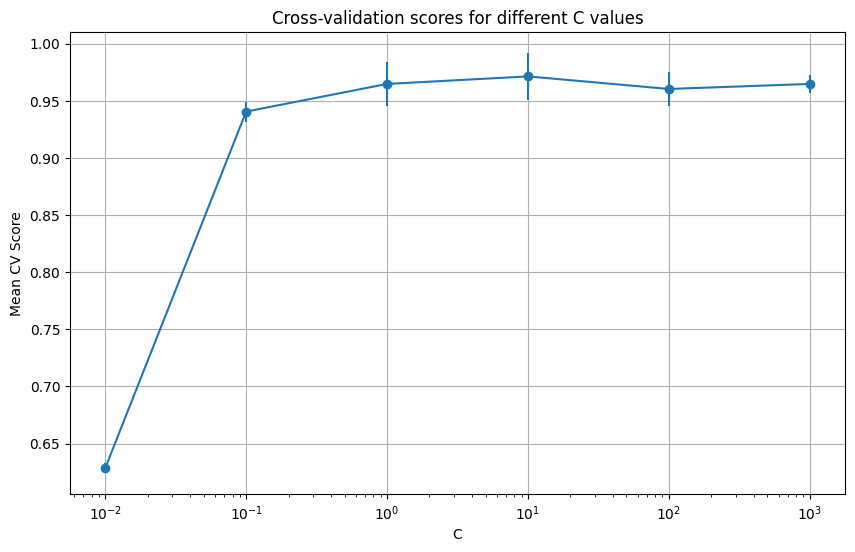

In [139]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

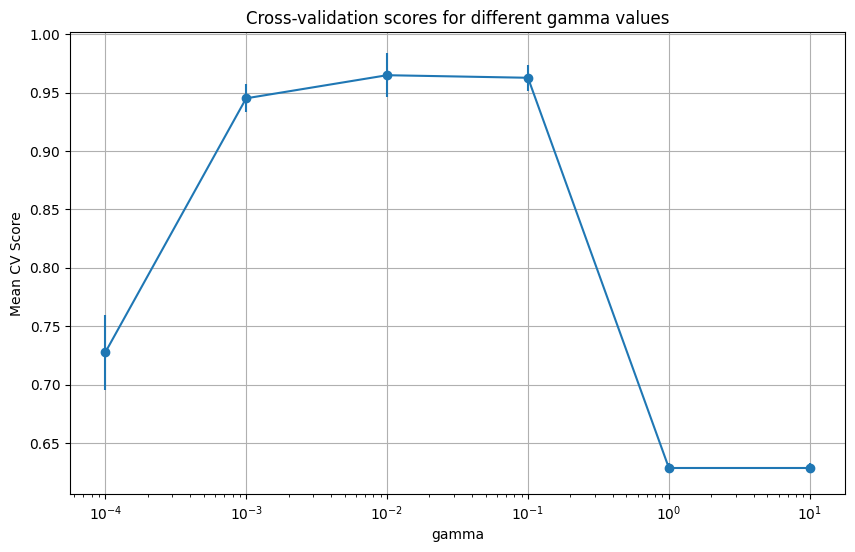

In [140]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [141]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [142]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [143]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [144]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [145]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [146]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000281BB368830>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000281BB36A580>,
                                        'kernel': ['rbf']},
                   random_state=42, scoring='accuracy')

In [147]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [148]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [149]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [150]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [151]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            6.787707
1          Random Search       0.971429       0.964912            0.243111
2  Bayesian Optimization       0.962637       0.956140           10.668557
3      Combined Approach       0.978022       0.982456                 NaN


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7804\3157594516.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)


# Part 8: Visualizing hyperparameter importance

In [152]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [153]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

SVC(C=47.479208101335, gamma=0.015041969444180125, probability=True,
    random_state=42)

In [154]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [155]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

RandomForestRegressor(random_state=42)

In [156]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

In [157]:
importances

array([0.14820819, 0.43057994, 0.21065977, 0.2105521 ])

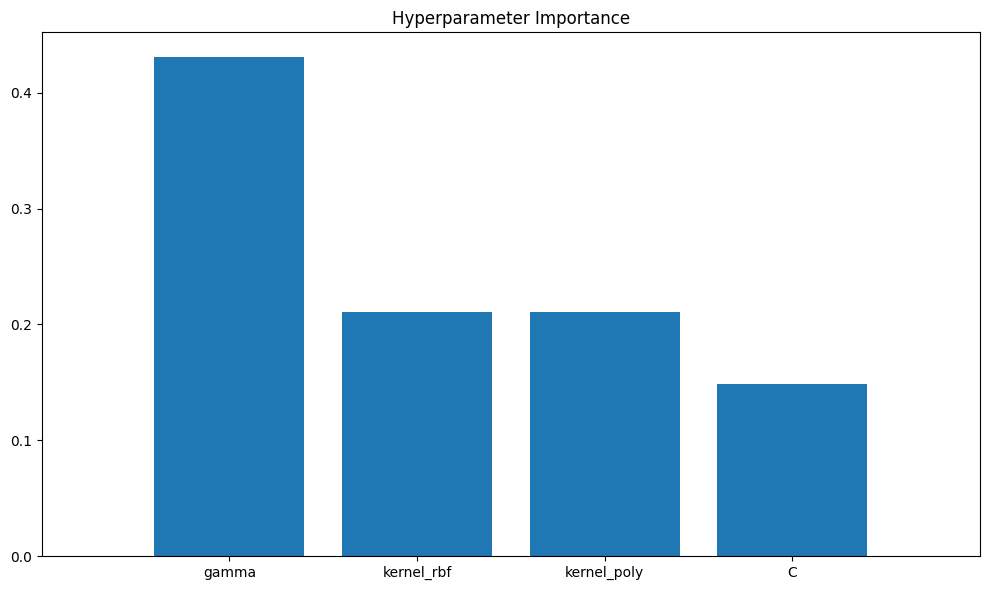

In [158]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [159]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7804\149670846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


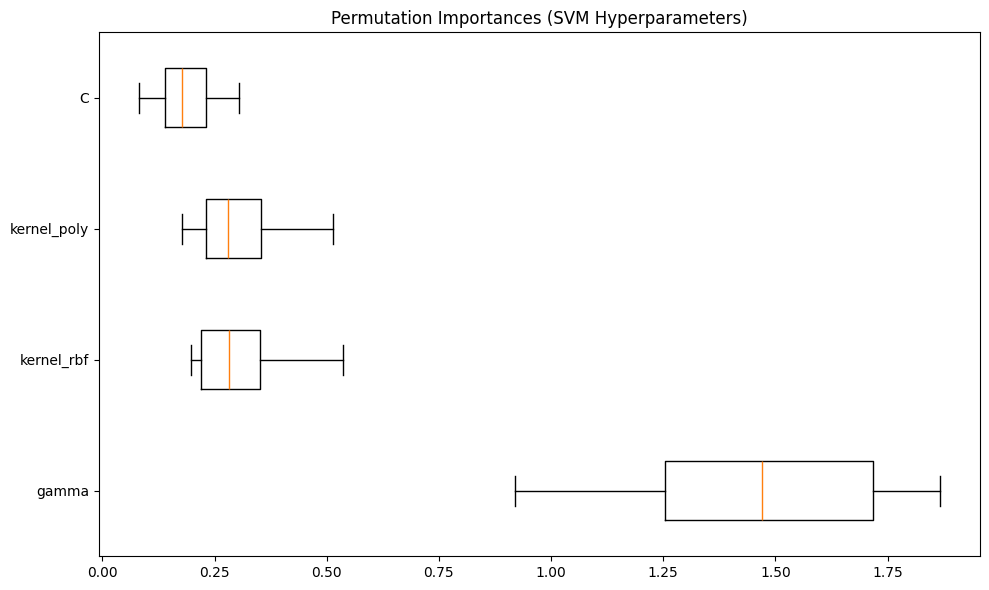

In [160]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [161]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [162]:
# ==============================================================================
# PART 1: SETUP AND DATA PREPARATION
# ==============================================================================
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Split the dataset into training and testing sets (80/20 split)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)


# TODO: Standardize the features using StandardScaler
scaler=StandardScaler()
X_scaled_train=scaler.fit_transform(X_train)
X_scaled_test=scaler.transform(X_test)

In [163]:
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
# Import models
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# TODO: Create a dictionary of baseline models with default parameters
# Include Ridge Regression, SVR, Random Forest, and Gradient Boosting
baseline_models={'Ridge':Ridge(),'SVR':SVR(),'Random Forest Regressor':RandomForestRegressor(),'Gradient Boosting':GradientBoostingRegressor()}

# TODO: Evaluate baseline models using 5-fold cross-validation
# Calculate and print mean and std of RMSE and R² for each model
# YOUR CODE HERE

evaluation_df=pd.DataFrame(columns=['Model','r2_mean','r2_std','rmse_mean','rmse_std'])
for name,model in baseline_models.items():
  scores=cross_validate(estimator=model,X=X_scaled_train,y=y_train,scoring=['r2','neg_mean_squared_error'])
  evaluation_df.loc[len(evaluation_df)]=[name,np.mean(scores['test_r2']),np.std(scores['test_r2']),np.mean(np.sqrt(np.abs(scores['test_neg_mean_squared_error']))),np.std(np.sqrt(np.abs(scores['test_neg_mean_squared_error'])))]


  #print("Model:",name,"\nR2 Score Mean:",np.mean(scores['test_r2']),"\n R2 Score STD:",np.std(scores['test_r2']),"\nRMSE Mean:",np.mean(np.sqrt(np.abs(scores['test_neg_mean_squared_error']))),"\nRMSE STD:",np.std(np.sqrt(np.abs(scores['test_neg_mean_squared_error']))))


print(evaluation_df)

baseline_r2=pd.DataFrame()
baseline_r2['Model']=evaluation_df['Model']
baseline_r2['baseline_score']=evaluation_df['r2_mean']
# TODO: Visualize baseline model performance with a bar plot

# answer in next cell

                     Model   r2_mean    r2_std  rmse_mean  rmse_std
0                    Ridge  0.611484  0.006460   0.720527  0.010280
1                      SVR  0.736814  0.004814   0.593056  0.010570
2  Random Forest Regressor  0.804157  0.005334   0.511493  0.006164
3        Gradient Boosting  0.786590  0.003240   0.534014  0.007146


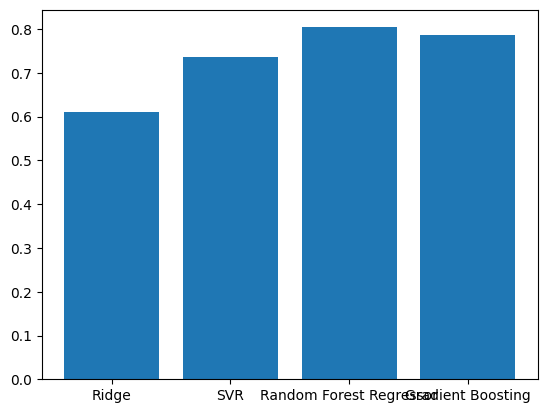

In [164]:
plt.figure()
plt.bar(evaluation_df['Model'],evaluation_df['r2_mean'])
plt.show()

In [165]:
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV
import time

# TODO: Define parameter grids for each model
# Ridge: alpha values
# SVR: C, gamma, and kernel values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE

params_grid_ridge={
    'alpha':[0.001,0.003,0.01,0.1,1]

}


param_grid_svr = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

param_grid_rf={
    'n_estimators':[10,100],
    'max_depth':[4,15],
    'min_samples_split':[9,15]
}

param_grid_gb={
    'n_estimators':[10,100],
    'max_depth':[4,15],
    'learning_rate':[0.001,0.003,0.01,0.1,1]
}




# TODO: Create a function that performs grid search for a given model and parameter grid
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE

def perform_grid_search(model,grid):
      start_time = time.time()
      coarse_grid_search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        cv=3,
        n_jobs=-1,
        verbose=0,
        scoring='r2')
      coarse_grid_search.fit(X_class_train_scaled, y_class_train)
      return coarse_grid_search.best_estimator_,coarse_grid_search.best_params_,coarse_grid_search.best_score_,(time.time()-start_time)



# TODO: Apply grid search to all models
# YOUR CODE HERE
evaluation_df_gs=pd.DataFrame(columns=['Model','best_score','time_taken'])
best_model,best_params,best_score,elapsed_time=perform_grid_search(Ridge(),params_grid_ridge);
evaluation_df_gs.loc[len(evaluation_df_gs)]=['Ridge',best_score,elapsed_time]


best_model,best_params,best_score,elapsed_time=perform_grid_search(SVR(),param_grid_svr);
evaluation_df_gs.loc[len(evaluation_df_gs)]=['SVR',best_score,elapsed_time]


best_model,best_params,best_score,elapsed_time=perform_grid_search(RandomForestRegressor(),param_grid_rf);
evaluation_df_gs.loc[len(evaluation_df_gs)]=['Random Forest Regressor',best_score,elapsed_time]



best_model,best_params,best_score,elapsed_time=perform_grid_search(GradientBoostingRegressor(),param_grid_gb);
evaluation_df_gs.loc[len(evaluation_df_gs)]=['Gradient Boosting',best_score,elapsed_time]



# TODO: Create a comparison table or visualization of grid search results
# YOUR CODE HERE
print(evaluation_df_gs)

                     Model  best_score  time_taken
0                    Ridge    0.720713    0.031140
1                      SVR    0.760761    0.280236
2  Random Forest Regressor    0.813649    1.286813
3        Gradient Boosting    0.814419    2.526123


In [166]:
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# TODO: Define parameter distributions for each model
# Ridge: alpha values
# SVR: C, gamma values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE

#==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV
import time

# TODO: Define parameter grids for each model
# Ridge: alpha values
# SVR: C, gamma, and kernel values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE

params_grid_ridge={
    'alpha':[0.001,0.003,0.01,0.1,1]

}


param_grid_svr = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

param_grid_rf={
    'n_estimators':[10,100],
    'max_depth':[4,15],
    'min_samples_split':[9,15]
}

param_grid_gb={
    'n_estimators':[10,100],
    'max_depth':[4,15],
    'learning_rate':[0.001,0.003,0.01,0.1,1]
}




# TODO: Create a function that performs grid search for a given model and parameter grid
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE

def perform_random_search(model,grid):
      start_time = time.time()
      refined_random_search = RandomizedSearchCV(
        estimator=svm,
        param_distributions=refined_param_dist,
        n_iter=20,
        cv=5,
        n_jobs=-1,
        verbose=0,
        random_state=42,
        scoring='r2')
      refined_random_search.fit(X_class_train_scaled, y_class_train)
      return refined_random_search.best_estimator_,refined_random_search.best_params_,refined_random_search.best_score_,(time.time()-start_time)




evaluation_df_rs=pd.DataFrame(columns=['Model','best_score','time_taken'])
best_model,best_params,best_score,elapsed_time=perform_random_search(Ridge(),params_grid_ridge);
evaluation_df_rs.loc[len(evaluation_df_rs)]=['Ridge',best_score,elapsed_time]


best_model,best_params,best_score,elapsed_time=perform_random_search(SVR(),param_grid_svr);
evaluation_df_rs.loc[len(evaluation_df_rs)]=['SVR',best_score,elapsed_time]


best_model,best_params,best_score,elapsed_time=perform_random_search(RandomForestRegressor(),param_grid_rf);
evaluation_df_rs.loc[len(evaluation_df_rs)]=['Random Forest Regressor',best_score,elapsed_time]



best_model,best_params,best_score,elapsed_time=perform_random_search(GradientBoostingRegressor(),param_grid_gb);
evaluation_df_rs.loc[len(evaluation_df_rs)]=['Gradient Boosting',best_score,elapsed_time]


print(evaluation_df_rs)


                     Model  best_score  time_taken
0                    Ridge    0.905971    0.127805
1                      SVR    0.905971    0.118454
2  Random Forest Regressor    0.905971    0.118441
3        Gradient Boosting    0.905971    0.115795


In [167]:
# ==============================================================================
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# ==============================================================================
# Install scikit-optimize if not already installed
pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# TODO: Define search spaces for each model using skopt's parameter types
# YOUR CODE HERE
search_spaces_svr = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

search_spaces_ridge={
    'alpha':Real(0.001,1,prior='log-uniform')
}

search_spaces_rf={
    'n_estimators':Integer(10,100,prior='uniform'),
    'max_depth':Integer(4,15,prior='uniform'),
    'min_samples_split':Integer(9,15,prior='uniform')
}

search_spaces_gb={
    'n_estimators':Integer(10,100, prior='uniform'),
    'max_depth':Integer(4,15,prior='uniform'),
    'learning_rate':Real(0.001,1,prior='log-uniform')
}



# TODO: Create a function that performs Bayesian optimization for a given model and search space
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE

def perform_bayes_search(model,search_spaces):
      start_time = time.time()
      bayes_search = BayesSearchCV(
          estimator=model,
          search_spaces=search_spaces,
          n_iter=20,
          cv=5,
          n_jobs=-1,
          verbose=0,
          random_state=42,
          scoring='r2',
          return_train_score=True )
      bayes_search.fit(X_class_train_scaled, y_class_train)
      return bayes_search.best_estimator_,bayes_search.best_params_,bayes_search.best_score_,(time.time()-start_time)




evaluation_df_bs=pd.DataFrame(columns=['Model','best_score','time_taken'])
best_model,best_params,best_score,elapsed_time=perform_bayes_search(Ridge(),search_spaces_ridge);
evaluation_df_bs.loc[len(evaluation_df_bs)]=['Ridge',best_score,elapsed_time]


best_model,best_params,best_score,elapsed_time=perform_bayes_search(SVR(),search_spaces_svr);
evaluation_df_bs.loc[len(evaluation_df_bs)]=['SVR',best_score,elapsed_time]


best_model,best_params,best_score,elapsed_time=perform_bayes_search(RandomForestRegressor(),search_spaces_rf);
evaluation_df_bs.loc[len(evaluation_df_bs)]=['Random Forest Regressor',best_score,elapsed_time]



best_model,best_params,best_score,elapsed_time=perform_bayes_search(GradientBoostingRegressor(),search_spaces_gb);
evaluation_df_bs.loc[len(evaluation_df_bs)]=['Gradient Boosting',best_score,elapsed_time]


print(evaluation_df_bs)



SyntaxError: invalid syntax (2464767910.py, line 5)

In [83]:
baseline_r2


,Model,baseline_score
0,Ridge,0.611484
1,SVR,0.736814
2,Random Forest Regressor,0.804157
3,Gradient Boosting,0.786590


                     Model  best_score  time_taken            Type
0                    Ridge    0.720713    0.027397      GridSearch
1                      SVR    0.760761    0.279223      GridSearch
2  Random Forest Regressor    0.821471    1.362544      GridSearch
3        Gradient Boosting    0.808072    2.468913      GridSearch
0                    Ridge    0.905971    0.117538    RandomSearch
1                      SVR    0.905971    0.110801    RandomSearch
2  Random Forest Regressor    0.905971    0.122009    RandomSearch
3        Gradient Boosting    0.905971    0.123475    RandomSearch
0                    Ridge    0.721721    5.895221  BayesianSearch
1                      SVR    0.675889   11.282217  BayesianSearch
2  Random Forest Regressor    0.821540   21.502782  BayesianSearch
3        Gradient Boosting    0.809527   47.199156  BayesianSearch
              Type                    Model  time_taken  best_score
0   BayesianSearch        Gradient Boosting   47.199156    0.

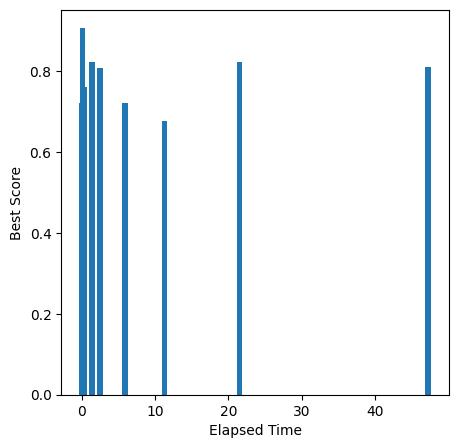

In [ ]:
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# TODO: Create a comprehensive comparison of all tuning methods
# Include metrics like best score, elapsed time, and improvement over baseline
# YOUR CODE HERE
evaluation_df_gs['Type']='GridSearch'
evaluation_df_rs['Type']='RandomSearch'
evaluation_df_bs['Type']='BayesianSearch'

combined_df=pd.concat([evaluation_df_gs,evaluation_df_rs,evaluation_df_bs])
print(combined_df)
# TODO: Visualize the comparison results
# Consider bar plots, scatter plots or heatmaps
# YOUR CODE HERE
comparison_df=pd.DataFrame()

# comparison_df['time_taken']=combined_df.groupby('Type')['time_taken'].mean()
# comparison_df['best_score']=combined_df.groupby('Type')['best_score'].mean()
comparison_df = combined_df.groupby(['Type', 'Model']).agg({
    'time_taken': 'mean',
    'best_score': 'mean'
}).reset_index()

print(comparison_df)


comparison_df = comparison_df.merge(baseline_r2, on='Model', how='left')
#comparison_df['baseline_score']=pd.Series(baseline_r2)
#print(comparison_df)


plt.figure(figsize=(5,5))

plt.bar(comparison_df['time_taken'],comparison_df['best_score'])
plt.xlabel('Elapsed Time')
plt.ylabel('Best Score')
plt.show()

Type
BayesianSearch    0.003648
GridSearch        1.023527
RandomSearch      1.458369
Name: efficiency, dtype: float64


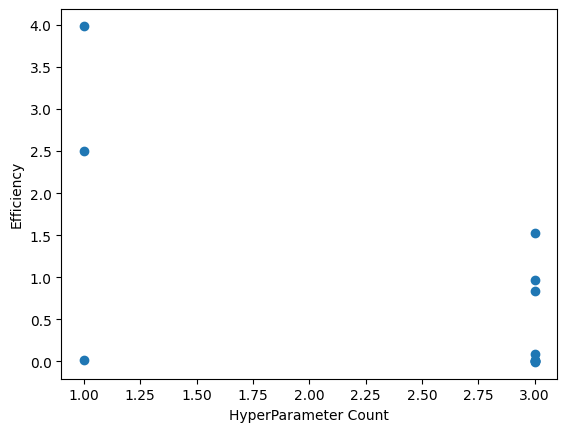

NameError: name 'true' is not defined

In [ ]:
# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# TODO: Calculate efficiency metrics for each tuning method
# Efficiency = (improvement in score) / (time spent tuning)
# YOUR CODE HERE

comparison_df['efficiency']=(comparison_df['best_score']-comparison_df['baseline_score'])/comparison_df['time_taken']
eff_df=comparison_df.groupby('Type')['efficiency'].mean()
print(eff_df)





# TODO: Analyze the relationship between number of hyperparameters and tuning efficiency
# YOUR CODE HERE
eff_df=pd.DataFrame(eff_df)
comparison_df['hp_count']=0
comparison_df.loc[comparison_df['Model']=='Ridge','hp_count']=1
comparison_df.loc[comparison_df['Model']=='SVR','hp_count']=3
comparison_df.loc[comparison_df['Model']=='Gradient Boosting','hp_count']=3
comparison_df.loc[comparison_df['Model']=='Random Forest Regressor','hp_count']=3

plt.figure()
plt.scatter(comparison_df['hp_count'],comparison_df['efficiency'])
plt.xlabel('HyperParameter Count')
plt.ylabel('Efficiency')
plt.show()




# Meta-learning: Predict which algorithm performs best based on a subset of data
# TODO: Create a function to extract dataset characteristics
# Examples: number of instances, number of features, feature statistics, etc.
# YOUR CODE HERE
def extract_characteristics(df):
  my_df=pd.DataFrame()
  my_df['instances_count']=df.shape[0]
  my_df['features_count']=df.shape[1]
  my_df['mean']=df.select_dtypes(include=[np.number])
  return my_df

# TODO: Generate multiple small datasets by sampling from the California housing data

data=fetch_california_housing(as_frame=true)
X=data.data
main_df=X.copy()
df=main_df.sample(n=100)


# Extract characteristics and record best algorithm for each sample



# YOUR CODE HERE

# TODO: Train a classifier to predict the best algorithm based on dataset characteristics
# YOUR CODE HERE


In [318]:
comparison_df

,Type,Model,time_taken,best_score,baseline_score,efficiency,hp_count
0,BayesianSearch,Gradient Boosting,61.707533,0.804562,0.786539,0.000292,3
1,BayesianSearch,Random Forest Regressor,59.624360,0.822006,0.803687,0.000307,3
2,BayesianSearch,Ridge,10.245175,0.721721,0.611484,0.010760,1
3,BayesianSearch,SVR,23.069972,0.675888,0.736814,-0.002641,3
4,GridSearch,Gradient Boosting,15.349781,0.806344,0.786539,0.001290,3
5,GridSearch,Random Forest Regressor,4.862763,0.820895,0.803687,0.003539,3
6,GridSearch,Ridge,3.008349,0.720713,0.611484,0.036309,1
7,GridSearch,SVR,2.949673,0.760761,0.736814,0.008118,3
8,RandomSearch,Gradient Boosting,0.651494,0.905971,0.786539,0.183321,3
9,RandomSearch,Random Forest Regressor,0.807900,0.905971,0.803687,0.126605,3


In [ ]:
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================

# TODO: Create an ensemble of your best tuned models
# Use a simple averaging approach or a more sophisticated method
# YOUR CODE HERE

# TODO: Evaluate the ensemble on the test set
# Compare its performance with individual models
# YOUR CODE HERE

In [ ]:
# ==============================================================================
# PART 10: CONCLUSION AND REPORTING
# ==============================================================================

# TODO: Summarize your findings
# Which model performed best?
# Which tuning method was most efficient?
# Was the ensemble better than individual models?
# What did you learn about hyperparameter spaces?
# YOUR ANSWER HERE

In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file